In [ ]:
# import google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# download dataset from roboflow
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.3 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
dataset = project.version(20).download("yolov8")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-20 in yolov8:: 100%|██████████| 756/756 [00:00<00:00, 3153.10it/s]

/content/football-players-detection-20


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

def understand_dataset(path, folder="train" ,image_index=None):
  """
  Function to view and ensure the dataset is what we need
  """
  # get the real path of the images
  real_path_img = f"{path}/{folder}/images"

  # get random image if no index provided
  if not image_index:
    image_index = random.randint(0, len(os.listdir(real_path_img)))

  # plot the image and the label
  image = Image.open(f"{real_path_img}/{os.listdir(real_path_img)[image_index]}")
  plt.figure(figsize=(10, 10))
  plt.imshow(image)
  plt.show()

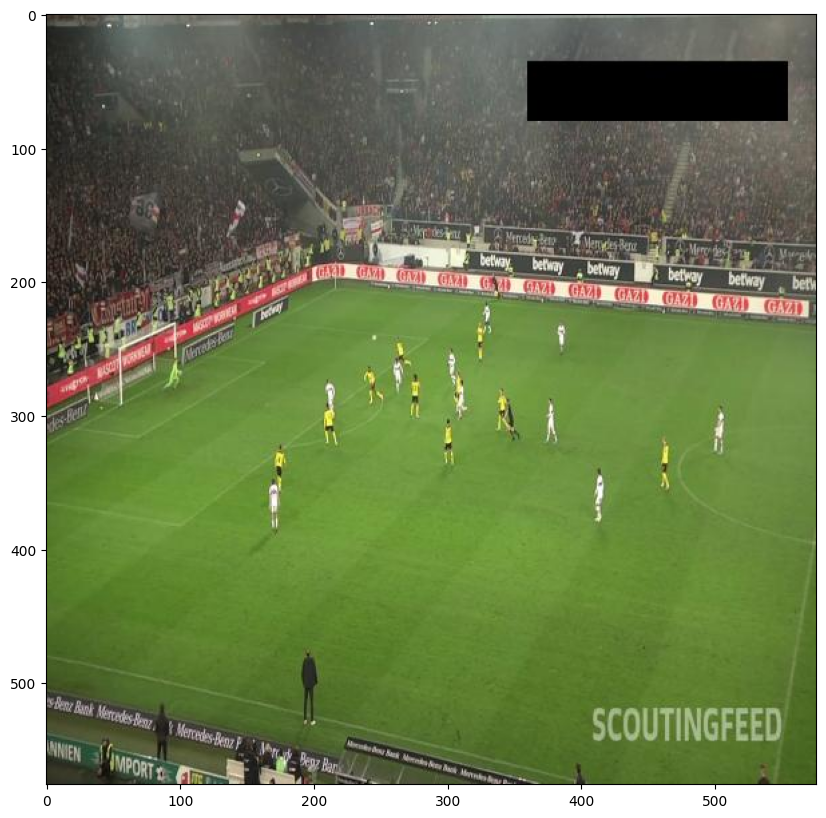

In [ ]:
understand_dataset("/content/football-players-detection-20")

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# get data file
data_yaml = "/content/football-players-detection-20/data.yaml"

model = YOLO("yolo11s.pt")

results = model.train(
    freeze="backbone",
    data=data_yaml,
    epochs=50,
    imgsz=640,
    cache=True,
    batch=-1,
    device=0,
    workers=8,
    lr0=0.01,
    optimizer="AdamW",
    patience=20,
    cos_lr=True,
    project=f"/content/drive/MyDrive/Stream/Colab Notebooks/Outputs",  # use the short name
    name="yolo_11_s_football")  # run name based on key


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/football-players-detection-20/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=backbone, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fals